## Theory

1. What is Logistic Regression, and how does it differ from Linear Regression?
--> A probabilistic classification algorithm used for binary classification.
It models the probability that:

𝑃(𝑌=1∣𝑋)
Linear Regression

A regression algorithm that predicts a continuous output:

𝑌=𝛽0+𝛽1𝑋1+...+𝛽𝑛

Linear Regression  
--> Predicts continuous values
--> Uses MSE loss 
--> Output unbounded           
--> Assumes Gaussian errors 

Logistic Regression              
--> Predicts probabilities (0–1)     
--> Uses Log Loss
--> Output bounded (0–1 via sigmoid) 
--> Assumes Bernoulli distribution 	​

2. What is the mathematical equation of Logistic Regression?
--> First compute linear combination:

𝑧 = 𝛽0 + 𝛽1𝑋1 +...+𝛽𝑛𝑋𝑛

Then apply Sigmoid function:

𝑃(𝑌=1∣𝑋)=1/1+𝑒^−𝑧

3. Why do we use the Sigmoid function in Logistic Regression?
--> Sigmoid:

𝜎(𝑧)=1/1+𝑒^−𝑧	​

Reasons:

Maps any real number → (0,1)

Interpretable as probability

Differentiable (needed for gradient descent)

Enables log-odds interpretation

4. What is the cost function of Logistic Regression?

-->Uses Log Loss (Binary Cross Entropy):

𝐽(𝜃)=−1/𝑚*∑_𝑖=1[𝑦_𝑖*log(𝑝_𝑖)+(1−𝑦𝑖)log⁡(1−𝑝𝑖)]

Why not MSE?
Because MSE makes optimization non-convex for classification.

5. What is Regularization in Logistic Regression? Why is it needed?

--> Regularization adds penalty to prevent overfitting.

General form:

𝐽(𝜃)+𝜆⋅𝑃𝑒𝑛𝑎𝑙𝑡𝑦 

Why?

Reduces variance

Prevents overfitting

Controls model complexity

6. Explain the difference between Lasso, Ridge, and Elastic Net regression.

--> Ridge	
𝜆 ∑𝜃^2(L2)	
Shrinks coefficients

Lasso	
𝜆∑|𝜃|(L1) 
feature selection

Elastic Net	
L1 + L2	
Hybrid approach

7. When should we use Elastic Net instead of Lasso or Ridge?

--> Use when:

Many correlated features

Lasso randomly selects one among correlated variables

Need both shrinkage + feature selection

Common in:

Genomics

High-dimensional data

8. What is the impact of the regularization parameter (1) in Logistic Regression?

--> Large λ → High bias, low variance (underfitting risk)

Small λ → Low bias, high variance (overfitting risk)

λ = 0 → No regularization

In sklearn:

C = 1/λ

Small C = Strong regularization

9. What are the key assumptions of Logistic Regression?

--> Binary outcome

Independent observations

Linear relationship between log-odds and predictors

No strong multicollinearity

Large sample size

10. What are some alternatives to Logistic Regression for classification tasks?

--> Decision Trees

Random Forest

Support Vector Machines

K-Nearest Neighbors

Naive Bayes

Neural Networks

Gradient Boosting (XGBoost, LightGBM)

11. What are Classification Evaluation Metrics?

--> Accuracy

Precision

Recall

F1 Score

ROC-AUC

Log Loss

Confusion Matrix

12. How does class imbalance affect Logistic Regression?

--> Problems:

Biased toward majority class

High accuracy but poor recall

Solutions:

Class weights

SMOTE

Undersampling

Adjust threshold

Use F1 / ROC-AUC instead of accuracy

13. What is Hyperparameter Tuning in Logistic Regression?

--> Important parameters:

C (regularization strength)

penalty (l1, l2, elasticnet)

solver

class_weight

Methods:

GridSearchCV

RandomizedSearchCV

Bayesian Optimization

14. What are different solvers in Logistic Regression? Which one should be used?

--> | Solver    | Supports         | Best For            |
    | --------- | ------------------ | ------------------- |
    | liblinear | L1, L2             | Small datasets      |
    | lbfgs     | L2                 | Default, multiclass |
    | saga      | L1, L2, ElasticNet | Large datasets      |
    | newton-cg | L2                 | Multiclass          |
    | sag       | L2                 | Large datasets      |

Recommendation:

Small dataset → liblinear

Large dataset → saga

Multiclass → lbfgs or saga

15. How is Logistic Regression extended for multiclass classification?

--> Two approaches:

One-vs-Rest (OvR)

Softmax (Multinomial Logistic Regression)

16. What are the advantages and disadvantages of Logistic Regression?

--> Advantages

Simple & interpretable

Fast training

Probabilistic output

Works well with linearly separable data

Disadvantages

Linear decision boundary

Sensitive to outliers

Poor with complex nonlinear data

17. What are some use cases of Logistic Regression?

--> Credit default prediction

Medical diagnosis

Spam detection

Customer churn

Fraud detection

Marketing response prediction

18. What is the difference between Softmax Regression and togistic Regression?

--> | Logistic                  | Softmax                               |
| ------------------------- | ------------------------------------- |
| Binary classification     | Multiclass classification             |
| Uses sigmoid              | Uses softmax function                 |
| Single probability output | Probability distribution over classes |

Softmax formula:

𝑃(𝑌=𝑘)=𝑒^𝑧_𝑘/∑_(𝑗=1^𝐾) 𝑒^𝑧_𝑗

19. How do we choose between One-vs-Rest (OvR) and Softmax for multiclass classification?

--> | OvR                                | Softmax                              |
| ---------------------------------- | ------------------------------------ |
| Trains multiple binary classifiers | Single unified model                 |
| Works well for imbalanced classes  | Better probabilistic interpretation  |
| Faster for small data              | Better for large multiclass problems |

Use Softmax when:

Classes are mutually exclusive

Need better probability estimates

20. How do we interpret coefficients in Logistic Regression?

--> Logistic regression models log-odds:

log(𝑝/1−𝑝)=𝛽0+𝛽1𝑋1+...

Interpretation:

β > 0 → Increases probability

β < 0 → Decreases probability

e^β → Odds Ratio

Example:
If β₁ = 0.7

𝑒^0.7 ≈ 2.01

Means odds increase by 2x per unit increase in X₁.

## Practical

In [343]:
import pandas as pd
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    StratifiedKFold
)

# Linear models
from sklearn.linear_model import (
    LogisticRegression,
    Lasso,
    LassoCV,
    Ridge,
    RidgeCV,
    ElasticNet,
    ElasticNetCV
)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    cohen_kappa_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

1. Write a Python program that loads a dataset, splits it into training and testing sets, applies Logistic Regression, and prints the model accuracy 



In [4]:
from sklearn.datasets import load_breast_cancer

In [5]:
breast_canc = load_breast_cancer()
breast_canc.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
breast_canc.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [7]:
breast_canc.target_names

array(['malignant', 'benign'], dtype='<U9')

In [333]:
breast_canc.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [8]:
breast_canc

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [296]:
df = pd.DataFrame(breast_canc.data, columns=breast_canc.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [297]:
df.shape

(569, 30)

In [298]:
df['target'] = breast_canc.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [299]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [300]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=1)


In [301]:
lgr = LogisticRegression()
lgr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [302]:
model = lgr.fit(x_train, y_train)
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [303]:
y_pred = model.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1])

In [34]:
print('Accuracy of the model is: ', accuracy_score(y_test, y_pred))

Accuracy of the model is:  0.951048951048951


2. Write a Python program to apply L1 regularization (Lasso) on a dataset using LogisticRegression(penalty='l1') and print the model accuracy 

In [19]:
l1 = Lasso()
l1

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [26]:
lgr1 = LogisticRegression(penalty='l1',solver='liblinear')
lgr1

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [27]:
model1 = lgr1.fit(x_train, y_train)
model1

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [29]:
y_pred_l1 = model1.predict(x_test)
y_pred_l1

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1])

In [32]:
print('Accuracy of the model is: ', accuracy_score(y_test, y_pred_l1))

Accuracy of the model is:  0.9440559440559441


3. Write a Python program to train Logistic Regression with L2 regularization (Ridge) using LogisticRegression(penalty='l2'). Print model accuracy and coefficients 

In [35]:
l2 = Ridge()
l2

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [36]:
lgr2 = LogisticRegression(penalty='l2')
lgr2

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
model2 = lgr2.fit(x_train, y_train)
model2 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
y_pred_l2 = model2.predict(x_test)
y_pred_l2

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1])

In [39]:
print('Accuracy of the model is: ', accuracy_score(y_test, y_pred_l2))

Accuracy of the model is:  0.951048951048951


4. Write a Python program to train Logistic Regression with Elastic Net Regularization (penalty='elasticnet') 

In [50]:
lgr3 = LogisticRegression(
    penalty='elasticnet',
    solver='saga',      # Required for elasticnet
    l1_ratio=0.5,
    max_iter=5000,
    random_state=42
)



In [51]:
model3 = lgr3.fit(x_train, y_train)
model3

,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


In [53]:
y_pred_enl = model3.predict(x_test)
y_pred_enl

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1])

In [54]:
print('Accuracy of the model is: ', accuracy_score(y_test, y_pred_enl))

Accuracy of the model is:  0.9370629370629371


5. Write a Python program to train a Logistic Regression model for multiclass classification using multi_class='ovr' 

In [57]:
lgr4 = LogisticRegression(multi_class='ovr', solver='lbfgs')
lgr4

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [58]:
model4 = lgr4.fit(x_train, y_train)
model4

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [59]:
y_pred_ovr = model4.predict(x_test)
y_pred_ovr

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1])

In [60]:
print('Accuracy of the model is: ', accuracy_score(y_test, y_pred_ovr))

Accuracy of the model is:  0.951048951048951


6. Write a Python program to apply GridSearchCV to tune the hyperparameters (C and penalty) of Logistic Regression. Print the best parameters and accuracy

In [71]:
params = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2', 'elasticnet']}

In [72]:
lgr5 = LogisticRegression()

In [73]:
grv = GridSearchCV(estimator=lgr5, param_grid=params, cv=5)
grv

,estimator,LogisticRegression()
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [74]:
model5 = grv.fit(x_train, y_train)
model5

,estimator,LogisticRegression()
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [75]:
y_pred_grv = model5.predict(x_test)
y_pred_grv

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1])

In [79]:
model5.best_params_

{'C': 1, 'penalty': 'l2'}

In [84]:
print(model5.best_score_)

0.9367989056087552


In [83]:
model5.best_estimator_

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [76]:
print('Accuracy of the model is: ', accuracy_score(y_test, y_pred_grv))

Accuracy of the model is:  0.951048951048951


7. Write a Python program to evaluate Logistic Regression using Stratified K-Fold Cross-Validation. Print the average accuracy

In [89]:
from sklearn.pipeline import Pipeline

In [90]:
pipeline = Pipeline([
    ('model', LogisticRegression(max_iter=5000, solver='lbfgs'))
])


In [87]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

In [88]:
lgr6 =LogisticRegression(max_iter=5000)

In [91]:
cv_scores = cross_val_score(
    pipeline,
    x,
    y,
    cv=skf,
    scoring='accuracy'
)


In [92]:
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

Cross-Validation Accuracy Scores: [0.94736842 0.94736842 0.93859649 0.95614035 0.96460177]
Mean Accuracy: 0.9508150908244062
Standard Deviation: 0.008848549666553825


8. Write a Python program to load a dataset from a CSV file, apply Logistic Regression, and evaluate its accuracy. 

In [199]:
data =  pd.read_csv('C:\\Users\\Hp\\Downloads\\Social_Network_Ads.csv')
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [200]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [201]:
df = le.fit_transform(data['Gender'])

In [202]:
data['Gender'] = df

In [203]:
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [204]:
x


,User ID,Gender,Age,EstimatedSalary
0,15624510,1,19,19000
1,15810944,1,35,20000
2,15668575,0,26,43000
3,15603246,0,27,57000
4,15804002,1,19,76000
...,...,...,...,...
395,15691863,0,46,41000
396,15706071,1,51,23000
397,15654296,0,50,20000
398,15755018,1,36,33000


In [205]:
x

,User ID,Gender,Age,EstimatedSalary
0,15624510,1,19,19000
1,15810944,1,35,20000
2,15668575,0,26,43000
3,15603246,0,27,57000
4,15804002,1,19,76000
...,...,...,...,...
395,15691863,0,46,41000
396,15706071,1,51,23000
397,15654296,0,50,20000
398,15755018,1,36,33000


In [206]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=1)

In [207]:
lgr7 = LogisticRegression()

In [208]:
model7 = lgr7.fit(x_train, y_train)
model7

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [210]:
y_pred_lgr7 = model7.predict(x_test)
y_pred_lgr7

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0])

In [211]:
print('Accuracy of the model is: ', accuracy_score(y_test, y_pred_lgr7))

Accuracy of the model is:  0.83


9. Write a Python program to apply RandomizedSearchCV for tuning hyperparameters (C, penalty, solver) in Logistic Regression. Print the best parameters and accuracy

In [141]:
params = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2', 'elasticnet'], 'solver': ['liblinear', 'saga', 'lbfgs']}

In [142]:
rsv = RandomizedSearchCV(estimator=lgr7, param_distributions=params, cv=5, n_iter=10, random_state=1)
rsv

,estimator,LogisticRegression()
,param_distributions,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['liblinear', 'saga', ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1
,error_score,nan


In [149]:
rsv.best_estimator_

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [150]:
rsv.best_params_

{'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}

In [151]:
rsv.best_score_

np.float64(0.8466666666666667)

In [152]:
model8 = rsv.fit(x_train, y_train)
model8

,estimator,LogisticRegression()
,param_distributions,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['liblinear', 'saga', ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1
,error_score,nan


In [153]:
y_pred_rsv = model8.predict(x_test)

In [155]:
accuracy_score(y_test, y_pred_rsv)

0.83

10. Write a Python program to implement One-vs-One (OvO) Multiclass Logistic Regression and print accuracy 

In [278]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.datasets import load_iris
df = load_iris()
df

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [159]:
df.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [160]:
df.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [279]:
data =pd.DataFrame(df.data, columns=df.feature_names)
data['target'] = df.target

In [280]:
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [281]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=1)


In [165]:
pipeline = Pipeline([
    ('ovo', OneVsOneClassifier(
        LogisticRegression(max_iter=5000, solver='lbfgs')
    ))
])

In [166]:
pipeline.fit(x_train, y_train)

,steps,"[('ovo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,estimator,LogisticRegre...max_iter=5000)
,n_jobs,None
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [170]:
y_pred = pipeline.predict(x_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0])

In [171]:
acc = accuracy_score(y_test, y_pred)
print('Accuracy of the model is: ', acc)

Accuracy of the model is:  0.9736842105263158


11.  Write a Python program to train a Logistic Regression model and visualize the confusion matrix for binary classification 

In [212]:
cm = confusion_matrix(y_test, y_pred_lgr7)

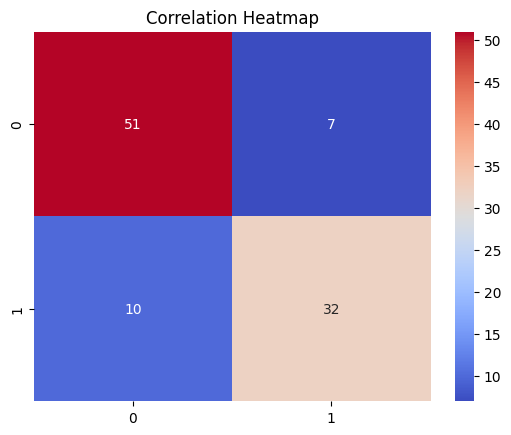

In [213]:
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

12. Write a Python program to train a Logistic Regression model and evaluate its performance using Precision, Recall, and F1-Score 

In [216]:
print('Precision: ', precision_score(y_test, y_pred_lgr7))


Precision:  0.8205128205128205


In [217]:
print('Recall: ', recall_score(y_test, y_pred_lgr7))

Recall:  0.7619047619047619


In [218]:
print('F1 Score: ', f1_score(y_test, y_pred_lgr7))

F1 Score:  0.7901234567901234


13. Write a Python program to train a Logistic Regression model on imbalanced data and apply class weights to improve model performance 

In [220]:
# Import libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

# Step 1: Create imbalanced dataset (90% vs 10%)
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    weights=[0.9, 0.1],   # Imbalance
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# Model 1: Without Class Weights
# -----------------------------
pipeline_no_weights = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

pipeline_no_weights.fit(X_train, y_train)
y_pred_no_weights = pipeline_no_weights.predict(X_test)

print("=== Without Class Weights ===")
print("Accuracy:", accuracy_score(y_test, y_pred_no_weights))
print(classification_report(y_test, y_pred_no_weights))

# -----------------------------
# Model 2: With Class Weights
# -----------------------------
pipeline_weights = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',   # Key parameter
        max_iter=5000
    ))
])

pipeline_weights.fit(X_train, y_train)
y_pred_weights = pipeline_weights.predict(X_test)

print("\n=== With Class Weights (Balanced) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_weights))
print(classification_report(y_test, y_pred_weights))


=== Without Class Weights ===
Accuracy: 0.917
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       897
           1       0.71      0.33      0.45       103

    accuracy                           0.92      1000
   macro avg       0.82      0.66      0.70      1000
weighted avg       0.90      0.92      0.90      1000


=== With Class Weights (Balanced) ===
Accuracy: 0.817
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       897
           1       0.34      0.85      0.49       103

    accuracy                           0.82      1000
   macro avg       0.66      0.83      0.69      1000
weighted avg       0.91      0.82      0.85      1000



14. Write a Python program to train Logistic Regression on the Titanic dataset, handle missing values, and evaluate performance 

In [275]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------------------------
# Step 1: Load Titanic dataset from seaborn
# -------------------------------------------------
df = sns.load_dataset("titanic")

# Drop rows where target is missing (rare case)
df = df.dropna(subset=["survived"])

# Target and features
y = df["survived"]
X = df.drop(columns=["survived"])

# -------------------------------------------------
# Step 2: Identify column types
# -------------------------------------------------
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns

# -------------------------------------------------
# Step 3: Preprocessing
# -------------------------------------------------
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# -------------------------------------------------
# Step 4: Full Pipeline
# -------------------------------------------------
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000))
])

# -------------------------------------------------
# Step 5: Train-Test Split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# -------------------------------------------------
# Step 6: Evaluation
# -------------------------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00        69

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179


Confusion Matrix:
 [[110   0]
 [  0  69]]


15. Write a Python program to apply feature scaling (Standardization) before training a Logistic Regression model. Evaluate its accuracy and compare results with and without scaling 

In [292]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()




In [309]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [307]:
x_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
562,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.094290,0.2128,0.07152,0.2602,1.205,2.362,22.65,0.004625,0.048440,0.073590,0.016080,0.02137,0.006142,17.52,42.79,128.70,915.0,0.14170,0.79170,1.17000,0.23560,0.4089,0.14090
291,14.96,19.10,97.03,687.3,0.08992,0.09823,0.05940,0.048190,0.1879,0.05852,0.2877,0.948,2.171,24.87,0.005332,0.021150,0.015360,0.011870,0.01522,0.002815,16.25,26.19,109.10,809.8,0.13130,0.30300,0.18040,0.14890,0.2962,0.08472
16,14.68,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.052590,0.1586,0.05922,0.4727,1.240,3.195,45.40,0.005718,0.011620,0.019980,0.011090,0.01410,0.002085,19.07,30.88,123.40,1138.0,0.14640,0.18710,0.29140,0.16090,0.3029,0.08216
546,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,0.2104,0.967,1.356,12.97,0.007086,0.007247,0.010120,0.005495,0.01560,0.002606,11.25,21.77,71.12,384.9,0.12850,0.08842,0.04384,0.02381,0.2681,0.07399
293,11.85,17.46,75.54,432.7,0.08372,0.05642,0.02688,0.022800,0.1875,0.05715,0.2070,1.238,1.234,13.88,0.007595,0.015000,0.014120,0.008578,0.01792,0.001784,13.06,25.75,84.35,517.8,0.13690,0.17580,0.13160,0.09140,0.3101,0.07007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,19.79,25.12,130.40,1192.0,0.10150,0.15890,0.25450,0.114900,0.2202,0.06113,0.4953,1.199,2.765,63.33,0.005033,0.031790,0.047550,0.010430,0.01578,0.003224,22.63,33.58,148.70,1589.0,0.12750,0.38610,0.56730,0.17320,0.3305,0.08465
144,10.75,14.97,68.26,355.3,0.07793,0.05139,0.02251,0.007875,0.1399,0.05688,0.2525,1.239,1.806,17.74,0.006547,0.017810,0.020180,0.005612,0.01671,0.002360,11.95,20.72,77.79,441.2,0.10760,0.12230,0.09755,0.03413,0.2300,0.06769
72,17.20,24.52,114.20,929.4,0.10710,0.18300,0.16920,0.079440,0.1927,0.06487,0.5907,1.041,3.705,69.47,0.005820,0.056160,0.042520,0.011270,0.01527,0.006299,23.32,33.82,151.60,1681.0,0.15850,0.73940,0.65660,0.18990,0.3313,0.13390
235,14.03,21.25,89.79,603.4,0.09070,0.06945,0.01462,0.018960,0.1517,0.05835,0.2589,1.503,1.667,22.07,0.007389,0.013830,0.007302,0.010040,0.01263,0.002925,15.33,30.28,98.27,715.5,0.12870,0.15130,0.06231,0.07963,0.2226,0.07617


In [295]:
y_train

562    0
291    1
16     0
546    1
293    1
      ..
129    0
144    1
72     0
235    1
37     1
Name: target, Length: 426, dtype: int64

In [308]:
lr = LogisticRegression(max_iter=5000)
model = lr.fit(x_train_scaled, y_train)

In [311]:
y_pred_model = model.predict(x_test_scaled)

In [313]:
print('Classification report before standard scaler of the model is: \n', classification_report(y_test, y_pred))

Classification report before standard scaler of the model is: 
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        55
           1       0.97      0.95      0.96        88

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



In [314]:
print('Classification report after standard scaler of the model is:\n ', classification_report(y_test, y_pred_model))

Classification report after standard scaler of the model is:
                precision    recall  f1-score   support

           0       0.98      0.96      0.97        55
           1       0.98      0.99      0.98        88

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



16. Write a Python program to train Logistic Regression and evaluate its performance using ROC-AUC score 

In [315]:
y_pred_prob = model.predict_proba(x_test_scaled)[:, 1]
y_pred_prob

array([8.50900006e-01, 1.02604016e-02, 9.89876508e-01, 5.09989221e-03,
       1.05437949e-01, 5.42124767e-03, 6.59428865e-05, 1.63081798e-01,
       9.93095704e-01, 9.74805952e-01, 9.98830168e-01, 1.96717254e-03,
       1.86698131e-02, 9.98119128e-01, 6.57829422e-01, 9.67632837e-01,
       9.99403909e-01, 9.91764830e-01, 9.99314866e-01, 6.84375254e-05,
       9.97480929e-01, 9.95435310e-01, 5.47005777e-05, 9.87028593e-01,
       7.76424076e-03, 9.69351385e-01, 9.76213298e-01, 8.46626050e-06,
       2.76496787e-13, 1.41847975e-02, 2.11660798e-09, 9.98909814e-01,
       1.46519161e-05, 3.29068626e-02, 9.99435188e-01, 9.99174464e-01,
       4.13192812e-03, 9.56996637e-01, 4.34317665e-01, 9.97252591e-01,
       9.99635156e-01, 8.38509378e-01, 9.71793361e-01, 9.99223892e-01,
       9.90926724e-01, 8.46116206e-04, 9.99953577e-01, 9.99903020e-01,
       9.73613696e-01, 2.58644784e-02, 1.87724807e-04, 4.18474427e-09,
       9.88074916e-01, 9.99919006e-01, 9.98409332e-01, 9.98897020e-01,
      

In [319]:
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9954545454545454


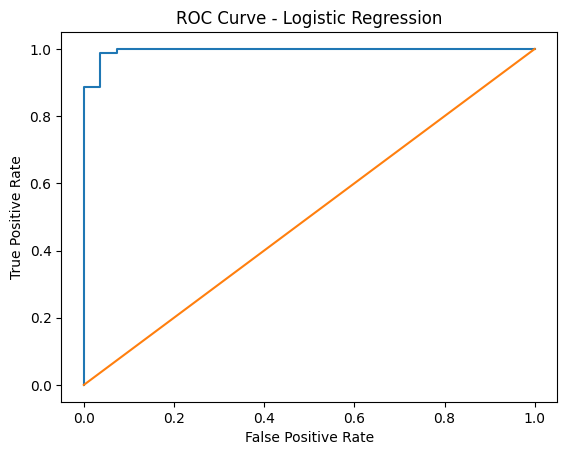

In [320]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

17. Write a Python program to train Logistic Regression using a custom learning rate (C=0.5) and evaluate accuracy 

In [322]:
lgr = LogisticRegression(C=0.5)

In [323]:
model = lgr.fit(x_train_scaled, y_train)
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [325]:
y_pred = model.predict(x_test_scaled)
y_pred

array([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1])

In [328]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.965034965034965


18. Write a Python program to train Logistic Regression and identify important features based on model coefficients 

In [330]:
model = LogisticRegression(max_iter=5000)
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [336]:
coefficients = model.coef_[0]

In [339]:
print(len(df.columns))
print(len(coefficients))


31
30


In [341]:
coefficients = model.coef_[0]
feature_names = x_train.columns   # If X_train is DataFrame


feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute Importance": np.abs(coefficients)
}).sort_values(by="Absolute Importance", ascending=False)

print(feature_importance.head(10))


                 Feature  Coefficient  Absolute Importance
10          radius error    -1.081638             1.081638
20          worst radius    -1.059264             1.059264
23            worst area    -0.961880             0.961880
21         worst texture    -0.956821             0.956821
27  worst concave points    -0.948427             0.948427
15     compactness error     0.916532             0.916532
22       worst perimeter    -0.911344             0.911344
26       worst concavity    -0.825859             0.825859
7    mean concave points    -0.784395             0.784395
28        worst symmetry    -0.780294             0.780294


In [342]:
print("Top Important Features:\n")
print(feature_importance.head(10))

Top Important Features:

                 Feature  Coefficient  Absolute Importance
10          radius error    -1.081638             1.081638
20          worst radius    -1.059264             1.059264
23            worst area    -0.961880             0.961880
21         worst texture    -0.956821             0.956821
27  worst concave points    -0.948427             0.948427
15     compactness error     0.916532             0.916532
22       worst perimeter    -0.911344             0.911344
26       worst concavity    -0.825859             0.825859
7    mean concave points    -0.784395             0.784395
28        worst symmetry    -0.780294             0.780294


19. Write a Python program to train Logistic Regression and evaluate its performance using Cohen’s Kappa Score 

In [344]:
accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Cohen's Kappa Score:", kappa)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.965034965034965
Cohen's Kappa Score: 0.9253731343283582

Confusion Matrix:
 [[51  4]
 [ 1 87]]


20. Write a Python program to train Logistic Regression and visualize the Precision-Recall Curve for binary classification

In [345]:
from sklearn.metrics import precision_recall_curve, average_precision_score



In [351]:
print("y_test length:", len(y_test))
print("y_pred_prob length:", len(y_pred_prob))


y_test length: 114
y_pred_prob length: 143


Average Precision (PR-AUC): 0.9970652078135953


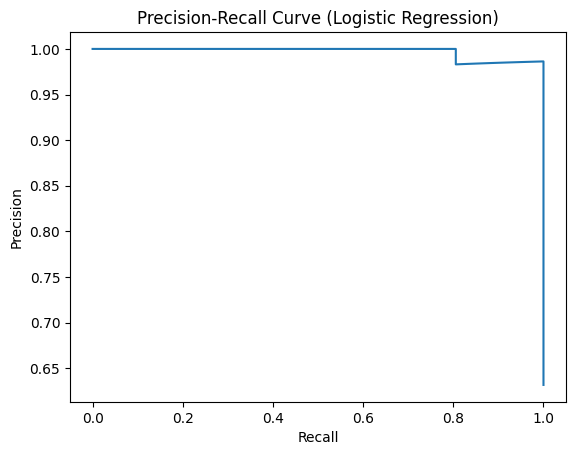

In [352]:
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print("Average Precision (PR-AUC):", pr_auc)

# -----------------------------------------
# Step 6: Plot Precision-Recall Curve
# -----------------------------------------
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.show()

21. Write a Python program to train Logistic Regression with different solvers (liblinear, saga, lbfgs) and compare their accuracy 

In [354]:

solvers = ["liblinear", "saga", "lbfgs"]

results = {}

for solver in solvers:
    model = LogisticRegression(
        solver=solver,
        max_iter=5000,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[solver] = accuracy



In [355]:
results_df = pd.DataFrame({
    "Solver": results.keys(),
    "Accuracy": results.values()
})

print(results_df)

      Solver  Accuracy
0  liblinear  0.982456
1       saga  0.982456
2      lbfgs  0.982456


22. Write a Python program to train Logistic Regression and evaluate its performance using Matthews Correlation Coefficient (MCC) 

In [357]:
from sklearn.metrics import matthews_corrcoef
accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print("Accuracy:", accuracy)
print("Matthews Correlation Coefficient (MCC):", mcc)



Accuracy: 0.9824561403508771
Matthews Correlation Coefficient (MCC): 0.9623015873015873


In [358]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[41  1]
 [ 1 71]]


23. Write a Python program to train Logistic Regression on both raw and standardized data. Compare their accuracy to see the impact of feature scaling 

In [359]:
model_raw = LogisticRegression(max_iter=5000)

model_raw.fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)

accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("Accuracy WITHOUT Standardization:", accuracy_raw)

# -----------------------------------------
# Model 2: Logistic Regression (Standardized Data)
# -----------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression(max_iter=5000)

model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("Accuracy WITH Standardization:", accuracy_scaled)

# -----------------------------------------
# Comparison
# -----------------------------------------
print("\nImpact of Scaling (Difference):",
      accuracy_scaled - accuracy_raw)


Accuracy WITHOUT Standardization: 0.9649122807017544
Accuracy WITH Standardization: 0.9824561403508771

Impact of Scaling (Difference): 0.01754385964912275


24. Write a Python program to train Logistic Regression and find the optimal C (regularization strength) using cross-validation 

In [360]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

# -----------------------------------------
# Step 3: Define Parameter Grid for C
# -----------------------------------------
param_grid = {
    'model__C': np.logspace(-4, 4, 20)  # Wide range of C values
}

# -----------------------------------------
# Step 4: GridSearch with Cross-Validation
# -----------------------------------------
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# -----------------------------------------
# Step 5: Best C and Evaluation
# -----------------------------------------
print("Best C value:", grid.best_params_['model__C'])
print("Best Cross-Validation Accuracy:", grid.best_score_)

# Evaluate on test set
y_pred = grid.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy with Optimal C:", test_accuracy)

Best C value: 0.08858667904100823
Best Cross-Validation Accuracy: 0.9802197802197803
Test Accuracy with Optimal C: 0.9736842105263158


25. Write a Python program to train Logistic Regression, save the trained model using joblib, and load it again to make predictions.

In [361]:
import joblib
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=5000))
])

# Train model
model.fit(X_train, y_train)

# Evaluate before saving
y_pred = model.predict(X_test)
print("Accuracy before saving:", accuracy_score(y_test, y_pred))

# -----------------------------------------
# Step 3: Save the trained model
# -----------------------------------------
joblib.dump(model, "logistic_model.pkl")
print("Model saved successfully!")

# -----------------------------------------
# Step 4: Load the saved model
# -----------------------------------------
loaded_model = joblib.load("logistic_model.pkl")
print("Model loaded successfully!")

# -----------------------------------------
# Step 5: Make predictions using loaded model
# -----------------------------------------
y_pred_loaded = loaded_model.predict(X_test)

print("Accuracy after loading:", accuracy_score(y_test, y_pred_loaded))

Accuracy before saving: 0.9824561403508771
Model saved successfully!
Model loaded successfully!
Accuracy after loading: 0.9824561403508771
